In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import to_rgba

from experiments.mech_interp.lib.synthetic import generate_composite_dataset, PERIOD_BINS

In [2]:
# ── Constants ─────────────────────────────────────────────────────────────────
PATCH_SIZE      = 16
CONTEXT_PATCHES = 32
PRED_PATCHES    = 4
T               = (CONTEXT_PATCHES + PRED_PATCHES) * PATCH_SIZE  # 576
t_axis          = np.arange(T)
ctx_end         = CONTEXT_PATCHES * PATCH_SIZE  # 512 — context/pred boundary

# Concept names and colors (one per column of concept_mask)
CONCEPTS = ['trend', 'level shift', 'AR(1)', 'seasonal', 'var shift', 'spike', 'rand walk']
CONCEPT_COLORS = [
    '#e6194b',  # trend      — red
    '#3cb44b',  # level      — green
    '#4363d8',  # ar1        — blue
    '#f58231',  # seasonal   — orange
    '#911eb4',  # var_shift  — purple
    '#42d4f4',  # spike      — cyan
    '#f032e6',  # rw         — magenta
]

In [3]:
# ── Helper: re-generate individual concept components for one example ─────────
# We reproduce the component signals given the stored labels so we can plot
# the decomposition without changing the generate_composite_dataset API.

def decompose_example(data: dict, i: int) -> dict:
    """Return {concept_name: component array [T]} for example i (zeros when absent)."""
    mask = data['concept_mask'][i]
    t = np.arange(T, dtype=np.float64)
    comps = {c: np.zeros(T) for c in CONCEPTS}

    # trend
    if mask[0]:
        comps['trend'] = data['slope'][i] * t / T

    # level shift — reconstruct from labels
    if mask[1]:
        t_norm = float(data['level_time_norm'][i])
        t_shift = int(round(t_norm * T))
        mag = float(data['level_magnitude'][i])
        comps['level shift'] = mag * (t >= t_shift).astype(np.float64)

    # ar1 — cannot perfectly reconstruct (noise is lost); skip component overlay
    # (shown as absent in decomposition, but marked active in concept bar)

    # seasonal
    if mask[3]:
        pidx = int(data['period_idx'][i])
        period_ts = PERIOD_BINS[pidx]
        amp = float(data['seasonal_amplitude'][i])
        phase = np.arctan2(float(data['phase_sin'][i]), float(data['phase_cos'][i]))
        comps['seasonal'] = amp * np.sin(2 * np.pi / period_ts * t + phase)

    # variance shift — cannot reconstruct (noise realisation lost); skip

    # spike
    if mask[5]:
        patch_idx = int(data['spike_patch_idx'][i])
        # we know the patch but not exact timestep; mark patch centre
        t_spike_approx = patch_idx * PATCH_SIZE + PATCH_SIZE // 2
        # series value minus approx smooth background gives spike height estimate
        # for viz purposes just show a vertical marker, not a component array

    return comps


def concept_bar_ax(ax, mask, height=0.08):
    """Draw a horizontal concept-presence bar below a time series axes."""
    for j, (active, color) in enumerate(zip(mask, CONCEPT_COLORS)):
        rect = mpatches.FancyBboxPatch(
            (j / 7, 0), 1 / 7, 1,
            boxstyle='round,pad=0.05',
            facecolor=color if active else '#dddddd',
            edgecolor='white', linewidth=1.5,
            transform=ax.transAxes, clip_on=False,
        )
        ax.add_patch(rect)
        ax.text(
            (j + 0.5) / 7, 0.5, CONCEPTS[j][0].upper(),
            ha='center', va='center', fontsize=6,
            color='white' if active else '#999999',
            fontweight='bold',
            transform=ax.transAxes,
        )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

## 1 · Overview: random examples across modes

/tmp/ipykernel_3939091/2307700200.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


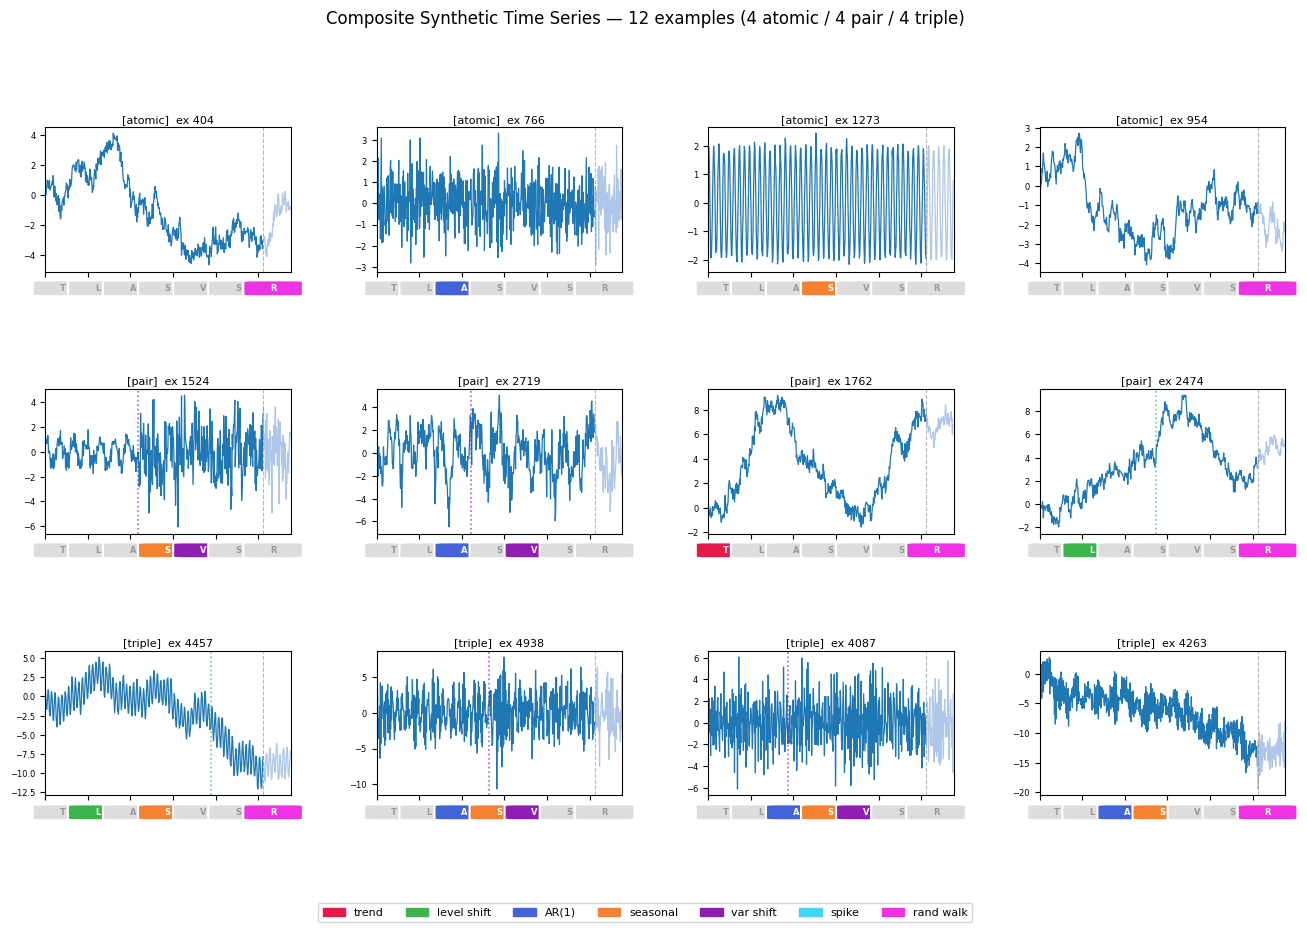

In [4]:
data = generate_composite_dataset(n=5000, seed=42,
                                  modes_dist = (0.3, 0.3, 0.4),
                                  concept_weights = (1.3, 0.7, 2, 4, 0.5, 0.8, 2))
counts = data['concept_mask'].sum(axis=1)

# Pick examples: 4 atomic, 4 pair, 4 triple
rng = np.random.default_rng(0)
atomic_idx  = rng.choice(np.where(counts == 1)[0], 4, replace=False)
pair_idx    = rng.choice(np.where(counts == 2)[0], 4, replace=False)
triple_idx  = rng.choice(np.where(counts == 3)[0], 4, replace=False)
example_idx = np.concatenate([atomic_idx, pair_idx, triple_idx])
mode_labels = ['atomic'] * 4 + ['pair'] * 4 + ['triple'] * 4

n_rows, n_cols = 3, 4
# Each subplot = series axes (tall) + concept bar axes (thin)
fig = plt.figure(figsize=(16, 9))
outer = gridspec.GridSpec(n_rows, n_cols, figure=fig, hspace=0.55, wspace=0.35)

for pos, (idx, mode) in enumerate(zip(example_idx, mode_labels)):
    row, col = divmod(pos, n_cols)
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[row, col],
        height_ratios=[10, 1], hspace=0.12
    )
    ax_ts  = fig.add_subplot(inner[0])
    ax_bar = fig.add_subplot(inner[1])

    series = data['series'][idx]
    mask   = data['concept_mask'][idx]
    active = [CONCEPTS[j] for j in range(7) if mask[j]]

    # Context region
    ax_ts.plot(t_axis[:ctx_end], series[:ctx_end], color='#1f77b4', lw=0.9)
    # Prediction region (lighter)
    ax_ts.plot(t_axis[ctx_end:], series[ctx_end:], color='#aec7e8', lw=0.9)
    # Context/pred boundary
    ax_ts.axvline(ctx_end, color='#888888', lw=0.8, ls='--', alpha=0.6)

    # Spike annotation
    if mask[5]:
        spike_patch = int(data['spike_patch_idx'][idx])
        spike_t_approx = spike_patch * PATCH_SIZE + PATCH_SIZE // 2
        if spike_t_approx < T:
            ax_ts.axvline(spike_t_approx, color=CONCEPT_COLORS[5], lw=1.2, alpha=0.7, ls=':')

    # Level shift annotation
    if mask[1]:
        t_norm = float(data['level_time_norm'][idx])
        t_shift = int(round(t_norm * T))
        ax_ts.axvline(t_shift, color=CONCEPT_COLORS[1], lw=1.2, alpha=0.7, ls=':')

    # Variance shift annotation
    if mask[4]:
        t_norm = float(data['var_shift_time_norm'][idx])
        t_var = int(round(t_norm * T))
        ax_ts.axvline(t_var, color=CONCEPT_COLORS[4], lw=1.2, alpha=0.7, ls=':')

    title = f'[{mode}]  ex {idx}'
    ax_ts.set_title(title, fontsize=8, pad=3)
    ax_ts.tick_params(labelsize=6)
    ax_ts.set_xlim(0, T)
    ax_ts.set_xlabel('', fontsize=0)

    concept_bar_ax(ax_bar, mask)

# Legend for concept colors
patches = [mpatches.Patch(color=c, label=n) for c, n in zip(CONCEPT_COLORS, CONCEPTS)]
fig.legend(handles=patches, loc='lower center', ncol=7, fontsize=8,
           frameon=True, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Composite Synthetic Time Series — 12 examples (4 atomic / 4 pair / 4 triple)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 2 · One-concept atomic examples (one per concept)

/tmp/ipykernel_3939091/4111740783.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


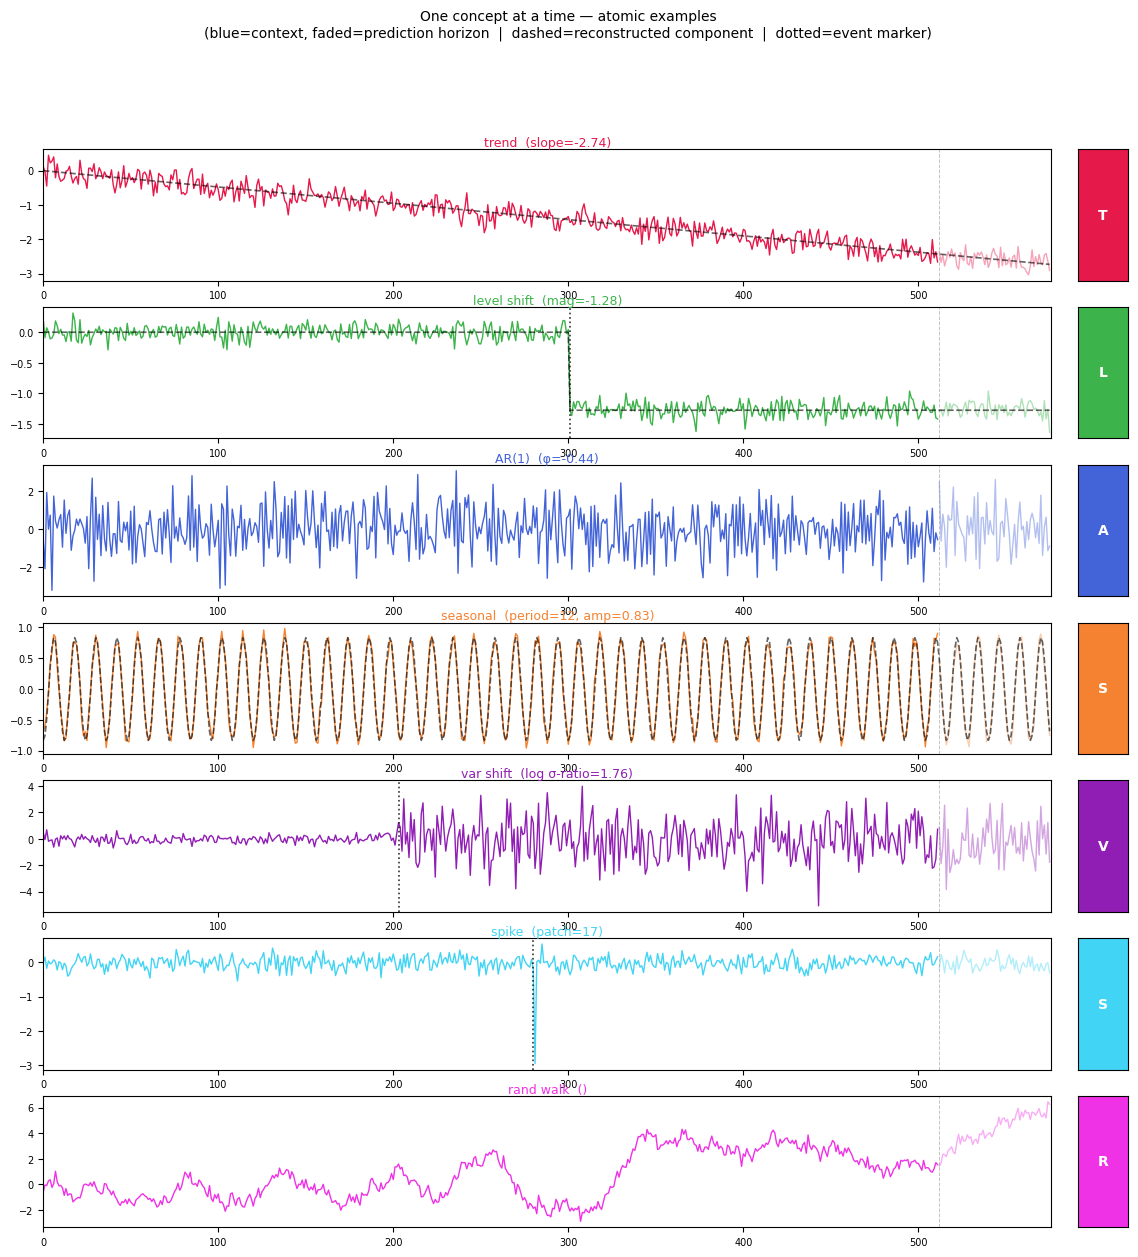

In [5]:
# For each concept, find an example that has ONLY that concept active
fig, axes = plt.subplots(7, 2, figsize=(14, 14),
                         gridspec_kw={'width_ratios': [20, 1], 'wspace': 0.05})

for j, (concept, color) in enumerate(zip(CONCEPTS, CONCEPT_COLORS)):
    # Find atomic examples with exactly this concept
    only_this = np.where(
        (data['concept_mask'][:, j] == True) & (counts == 1)
    )[0]
    idx = only_this[0] if len(only_this) > 0 else None

    ax_ts  = axes[j, 0]
    ax_leg = axes[j, 1]

    if idx is None:
        ax_ts.text(0.5, 0.5, 'no atomic example found',
                   ha='center', va='center', transform=ax_ts.transAxes)
    else:
        series = data['series'][idx]
        ax_ts.plot(t_axis[:ctx_end], series[:ctx_end], color=color, lw=1.0)
        ax_ts.plot(t_axis[ctx_end:], series[ctx_end:], color=color, lw=1.0, alpha=0.4)
        ax_ts.axvline(ctx_end, color='#888888', lw=0.7, ls='--', alpha=0.5)

        # Overlay reconstructible components
        comps = decompose_example(data, idx)
        comp_arr = comps[concept]
        if np.any(comp_arr != 0):
            ax_ts.plot(t_axis, comp_arr, color='black', lw=1.2, ls='--',
                       alpha=0.6, label='component')

        # Annotate change-point events
        if j == 1:  # level shift
            t_shift = int(round(float(data['level_time_norm'][idx]) * T))
            ax_ts.axvline(t_shift, color='black', lw=1.2, ls=':', alpha=0.8)
        if j == 4:  # var shift
            t_var = int(round(float(data['var_shift_time_norm'][idx]) * T))
            ax_ts.axvline(t_var, color='black', lw=1.2, ls=':', alpha=0.8)
        if j == 5:  # spike
            t_sp = int(data['spike_patch_idx'][idx]) * PATCH_SIZE + PATCH_SIZE // 2
            ax_ts.axvline(t_sp, color='black', lw=1.2, ls=':', alpha=0.8)

        # Label with key parameter value
        label_str = ''
        if j == 0: label_str = f'slope={data["slope"][idx]:.2f}'
        elif j == 1: label_str = f'mag={data["level_magnitude"][idx]:.2f}'
        elif j == 2: label_str = f'φ={data["ar_phi"][idx]:.2f}'
        elif j == 3: label_str = f'period={PERIOD_BINS[data["period_idx"][idx]]}, amp={data["seasonal_amplitude"][idx]:.2f}'
        elif j == 4: label_str = f'log σ-ratio={data["log_sigma_ratio"][idx]:.2f}'
        elif j == 5: label_str = f'patch={data["spike_patch_idx"][idx]}'
        elif j == 6: label_str = ''

        ax_ts.set_title(f'{concept}  ({label_str})', color=color, fontsize=9, pad=2)
        ax_ts.tick_params(labelsize=7)
        ax_ts.set_xlim(0, T)

    # Colored concept tab on the right
    ax_leg.set_facecolor(color)
    ax_leg.text(0.5, 0.5, concept[0].upper(), ha='center', va='center',
                color='white', fontsize=10, fontweight='bold',
                transform=ax_leg.transAxes)
    ax_leg.set_xticks([]); ax_leg.set_yticks([])

fig.suptitle('One concept at a time — atomic examples\n'
             '(blue=context, faded=prediction horizon  |  dashed=reconstructed component  |  dotted=event marker)',
             fontsize=10)
plt.tight_layout()
plt.show()

## 3 · Detailed decomposition for a selected example

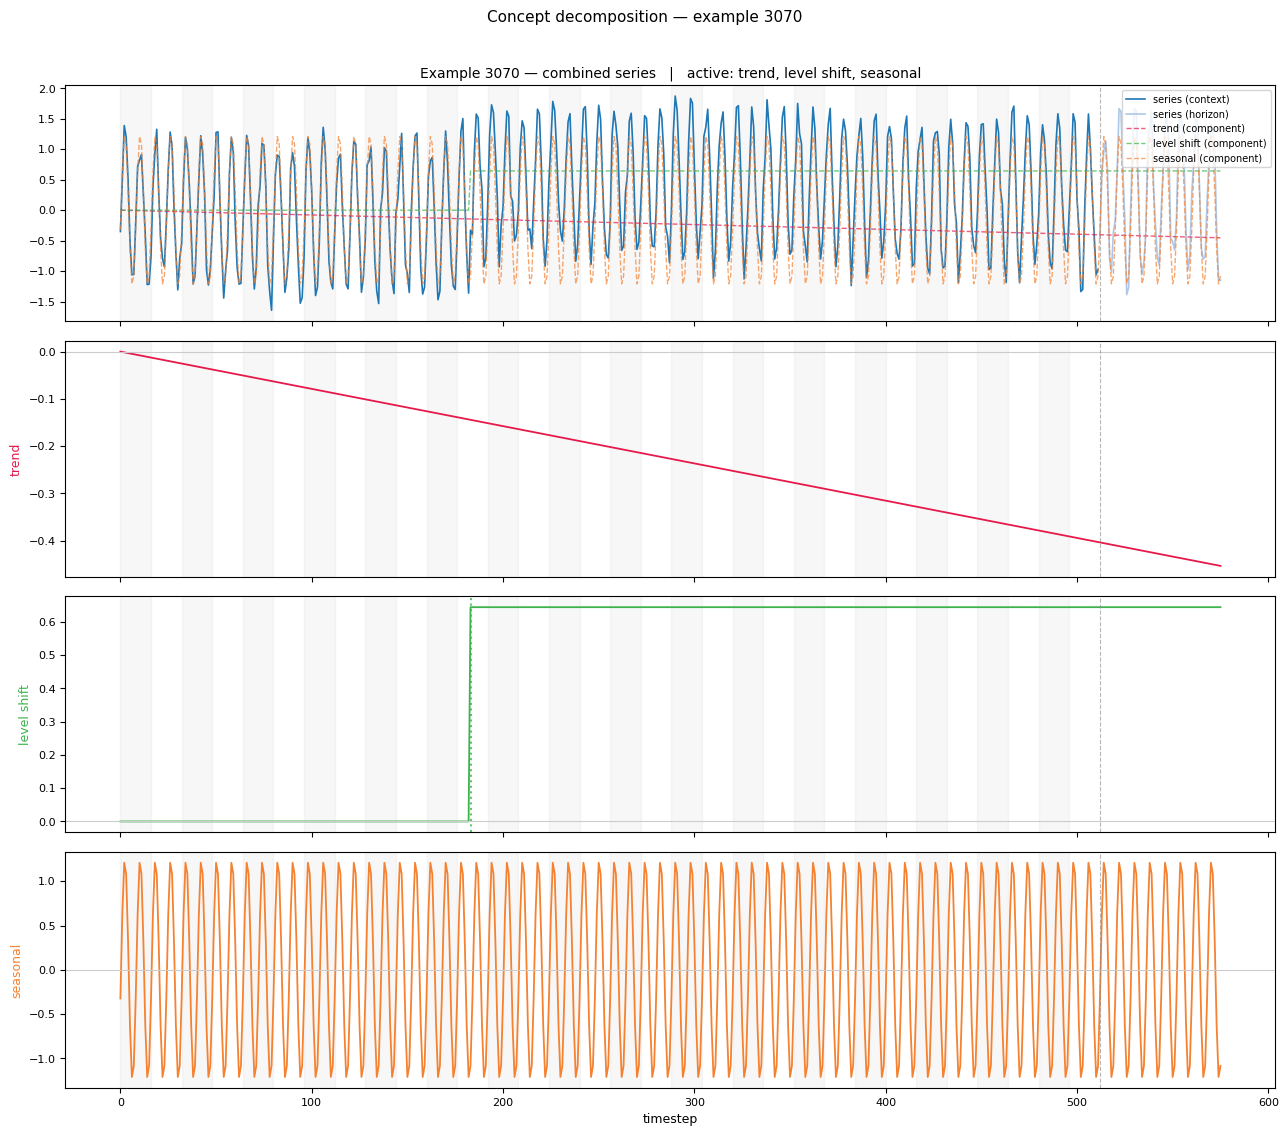

In [6]:
# Pick a triple-mode example with trend + seasonal + level_shift (concepts 0,1,3)
# for a clean, visually interesting decomposition
target_mask = np.array([1, 1, 0, 1, 0, 0, 0], dtype=bool)
candidates = np.where(np.all(data['concept_mask'] == target_mask, axis=1))[0]
if len(candidates) == 0:
    # fall back to any triple example
    candidates = np.where(counts == 3)[0]
chosen = int(candidates[0])

series    = data['series'][chosen]
mask      = data['concept_mask'][chosen]
active    = [CONCEPTS[j] for j in range(7) if mask[j]]
comps     = decompose_example(data, chosen)

# Reconstructible components to overlay
recon_concepts = ['trend', 'level shift', 'seasonal']  # AR1 / var_shift / rw not reconstructible
recon_present  = [c for c in recon_concepts if mask[CONCEPTS.index(c)]]

n_panels = 1 + len(recon_present)  # combined series + one panel per reconstructible component
fig, axes = plt.subplots(n_panels, 1, figsize=(13, 2.8 * n_panels), sharex=True)
if n_panels == 1:
    axes = [axes]

# Top panel: full series
ax = axes[0]
ax.plot(t_axis[:ctx_end], series[:ctx_end], color='#1f77b4', lw=1.2, label='series (context)')
ax.plot(t_axis[ctx_end:], series[ctx_end:], color='#aec7e8', lw=1.2, label='series (horizon)')
ax.axvline(ctx_end, color='#888888', lw=0.8, ls='--', alpha=0.6)
# Overlay all reconstructible components on the combined plot
for c in recon_present:
    ci = CONCEPTS.index(c)
    ax.plot(t_axis, comps[c], color=CONCEPT_COLORS[ci], lw=1.0, ls='--', alpha=0.7, label=f'{c} (component)')
ax.set_title(f'Example {chosen} — combined series   |   active: {", ".join(active)}', fontsize=10)
ax.legend(fontsize=7, loc='upper right')
ax.tick_params(labelsize=8)

# Component panels
for panel_i, c in enumerate(recon_present):
    ci = CONCEPTS.index(c)
    ax = axes[panel_i + 1]
    ax.plot(t_axis, comps[c], color=CONCEPT_COLORS[ci], lw=1.3)
    ax.axhline(0, color='#cccccc', lw=0.8)
    ax.axvline(ctx_end, color='#888888', lw=0.8, ls='--', alpha=0.6)
    if c == 'level shift':
        t_shift = int(round(float(data['level_time_norm'][chosen]) * T))
        ax.axvline(t_shift, color=CONCEPT_COLORS[ci], lw=1.5, ls=':', alpha=0.8)
    ax.set_ylabel(c, fontsize=9, color=CONCEPT_COLORS[ci])
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('timestep', fontsize=9)

# Patch grid
for ax in axes:
    for p in range(0, ctx_end, PATCH_SIZE):
        ax.axvspan(p, p + PATCH_SIZE, alpha=0.03,
                   color='#000000' if (p // PATCH_SIZE) % 2 == 0 else '#ffffff')

fig.suptitle(f'Concept decomposition — example {chosen}', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 4 · Label distributions per concept

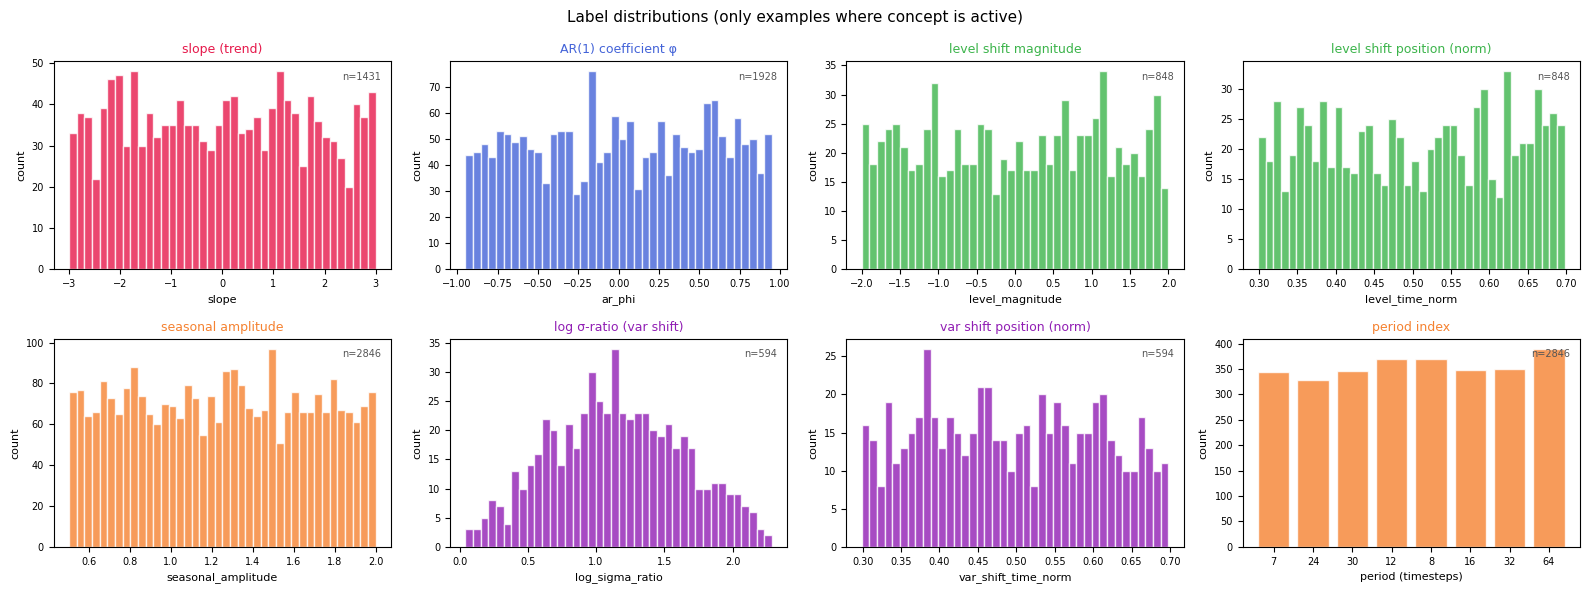

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.ravel()

plots = [
    ('slope',               0, 'slope (trend)'),
    ('ar_phi',              2, 'AR(1) coefficient φ'),
    ('level_magnitude',     1, 'level shift magnitude'),
    ('level_time_norm',     1, 'level shift position (norm)'),
    ('seasonal_amplitude',  3, 'seasonal amplitude'),
    ('log_sigma_ratio',     4, 'log σ-ratio (var shift)'),
    ('var_shift_time_norm', 4, 'var shift position (norm)'),
    ('period_idx',          3, 'period index'),
]

for ax, (key, concept_col, title) in zip(axes, plots):
    present_mask = data['concept_mask'][:, concept_col]
    vals = data[key][present_mask]
    color = CONCEPT_COLORS[concept_col]

    if key == 'period_idx':
        # Bar chart for categorical
        unique, cnts = np.unique(vals, return_counts=True)
        ax.bar(unique, cnts, color=color, alpha=0.8, edgecolor='white')
        ax.set_xticks(unique)
        ax.set_xticklabels([f'{PERIOD_BINS[int(u)]}' for u in unique], fontsize=7)
        ax.set_xlabel('period (timesteps)', fontsize=8)
    else:
        finite_vals = vals[np.isfinite(vals)]
        ax.hist(finite_vals, bins=40, color=color, alpha=0.8, edgecolor='white')
        ax.set_xlabel(key, fontsize=8)

    ax.set_title(title, fontsize=9, color=color)
    ax.set_ylabel('count', fontsize=8)
    ax.tick_params(labelsize=7)
    n_present = int(present_mask.sum())
    ax.text(0.97, 0.95, f'n={n_present}', ha='right', va='top',
            transform=ax.transAxes, fontsize=7, color='#555555')

fig.suptitle('Label distributions (only examples where concept is active)', fontsize=11)
plt.tight_layout()
plt.show()

## 5 · Concept co-occurrence heatmap

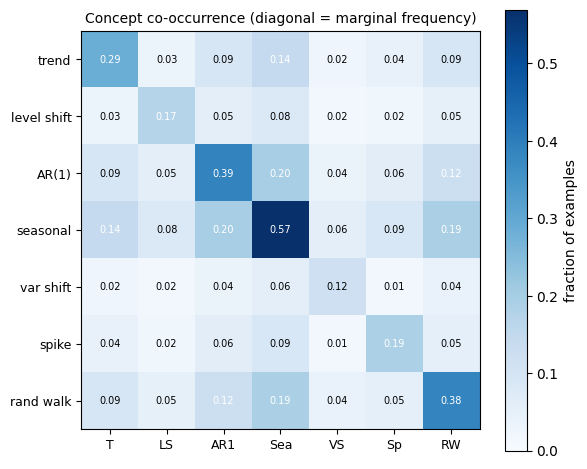

In [8]:
cm = data['concept_mask'].astype(float)
cooccur = (cm.T @ cm) / len(cm)  # [7, 7] — fraction of examples where both active

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cooccur, vmin=0, cmap='Blues')
plt.colorbar(im, ax=ax, label='fraction of examples')

short = ['T', 'LS', 'AR1', 'Sea', 'VS', 'Sp', 'RW']
ax.set_xticks(range(7)); ax.set_xticklabels(short, fontsize=9)
ax.set_yticks(range(7)); ax.set_yticklabels(CONCEPTS, fontsize=9)

for i in range(7):
    for j in range(7):
        ax.text(j, i, f'{cooccur[i, j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if cooccur[i, j] > 0.12 else 'black')

ax.set_title('Concept co-occurrence (diagonal = marginal frequency)', fontsize=10)
plt.tight_layout()
plt.show()